In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
path_file = r"..\mediciones\clase2\clean\mediciones_parte1_clean.csv"
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,frecuencia,vpp,vpp_error
0,35.0,10.0,0.3
1,36.0,32.0,1.0
2,37.0,74.0,2.0
3,38.0,188.0,6.0
4,38.1,202.0,6.0


### Funciones

In [4]:
def modelo_resonancia(f, c, f0, gamma, y0):
    omega = 2 * np.pi * f  
    omega0 = 2 * np.pi * f0
    denom = (omega0**2 - omega**2) ** 2 + (omega * gamma) ** 2
    return c * (1.0 / denom) + y0

In [6]:
# 1. f0  (frecuencia de resonancia aproximada)
f0 = 39.5  # kHz
# 2. gamma  (ancho angular del pico)
gamma = 2 * np.pi * 1.6  
# 3. y0  (base)
y0 = 30.0  # mV
# 4. C inicial (constante)
# En el pico (f = f0), la función vale: Vpp_max ≈ C / (omega0 * gamma)^2 + y0
# Despejando C para Vpp_max ≈ 850 mV:
vpp_max = datos['vpp'].max()
omega0 = 2 * np.pi * f0
c = (vpp_max - y0) * ((omega0 * gamma) ** 2)

p0 = [c, f0, gamma, y0]

In [7]:
# Ajuste con curve_fit
popt, pcov = curve_fit(
    modelo_resonancia,
    datos["frecuencia"],
    datos["vpp"],
    p0=p0,
    sigma=datos["vpp_error"],
    absolute_sigma=True,
)

In [9]:
a, f0, sigma, y0 = popt
errores = np.sqrt(np.diag(pcov))
f0_error = errores[1]

In [14]:
# Extraer los valores óptimos y sus errores (raíz de la diagonal de la covarianza)
A_opt, f0_opt, sigma_opt, y0_opt = popt
errores = np.sqrt(np.diag(pcov))
df0 = errores[1]  # Error de la frecuencia característica f0

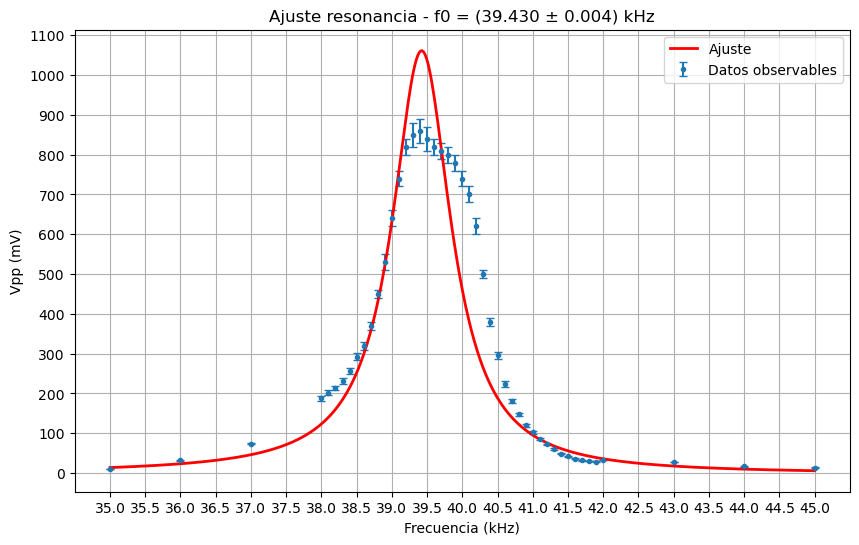

In [13]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = modelo_resonancia(f_fit, *popt)

plt.figure(figsize=(10, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label='Ajuste', linewidth=2)

plt.xticks(np.arange(35, 45.5, 0.5))
plt.yticks(np.arange(0, 1200, 100))

plt.title(f'Ajuste resonancia - f0 = ({f0:.3f} ± {f0_error:.3f}) kHz')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Vpp (mV)')

plt.grid(True)
plt.legend()

# guardamos 
#path_save = r"..\graficos\clase2\ajuste_gaussiano_rango_maximo.png"
#plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()